# Cycle Count of Flash Attention

记录Flash Attention子算子在Rocket+Gemmini+Saturn架构下的运行周期数并可视化，包括各类**调度逻辑**的开销

可视化包括：

- 随相关参数变化，耗时的绝对变化、占比变化
- **Roofline Model**

Parameters:
- Sequence Length: 128, 256, 512, 1024, 2048 (tile shape fixed at 128\*128)
- Tile Shape: 8\*8, 16\*16, 32\*32, 64\*64, 128\*128, 128x64, 256\*256 (seq length fixed at 1k)
- Head Dim: 64

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Forward Inner Calculation Function

统计Flash Attention循环内部计算模块的各个子操作的耗时，仅进行单次分块计算

Parameters: different tile shape `BR` `BC`

In [4]:
df_inner = pd.read_excel(io="data/single_head_cycles_cnt.xlsx", sheet_name="Inner", header=0, index_col=0)
df_inner.drop(axis='index', index="单位：周期数 / Head Dimension取64 / Gemmini采用默认INT8 WS配置 / Saturn VLEN=256", inplace=True)
df_inner.drop(index="rowmax(S)\n(CPU)", inplace=True)
df_inner.drop(index="exp(S - m)\n(CPU)", inplace=True)
df_inner.drop(index="rowsum(P)\n(CPU)", inplace=True)
df_inner.drop(index="normalization\n(CPU)", inplace=True)
df_inner

,1x5,8x8,16x16,16x64,64x16,64x64,64x128,128x64,128x128,256x256
QK^T,1047.0,1230.0,1358.0,1282.0,1950.0,3895.0,7491.0,6079.0,10940.0,48537.0
PV,624.0,756.0,1009.0,1226.0,1711.0,3787.0,5940.0,6315.0,10590.0,25999.0
softmax(S)\n(RVV),477.0,3127.0,6664.0,11923.0,26356.0,46961.0,75170.0,93493.0,149269.0,533445.0
rowmax(S)\n(RVV),136.0,806.0,1619.0,2147.0,6385.0,8136.0,10255.0,15878.0,19296.0,52455.0
exp(S - m)\n(RVV),152.0,963.0,2072.0,6133.0,7967.0,24293.0,48477.0,48473.0,96943.0,396106.0
rowsum(P)\n(RVV),161.0,1075.0,2086.0,2289.0,7991.0,8905.0,10237.0,17761.0,20574.0,80068.0
normalization\n(RVV),40.0,381.0,706.0,1367.0,3120.0,3397.0,5070.0,6085.0,9831.0,43167.0


### 绝对周期数随分块大小的变化

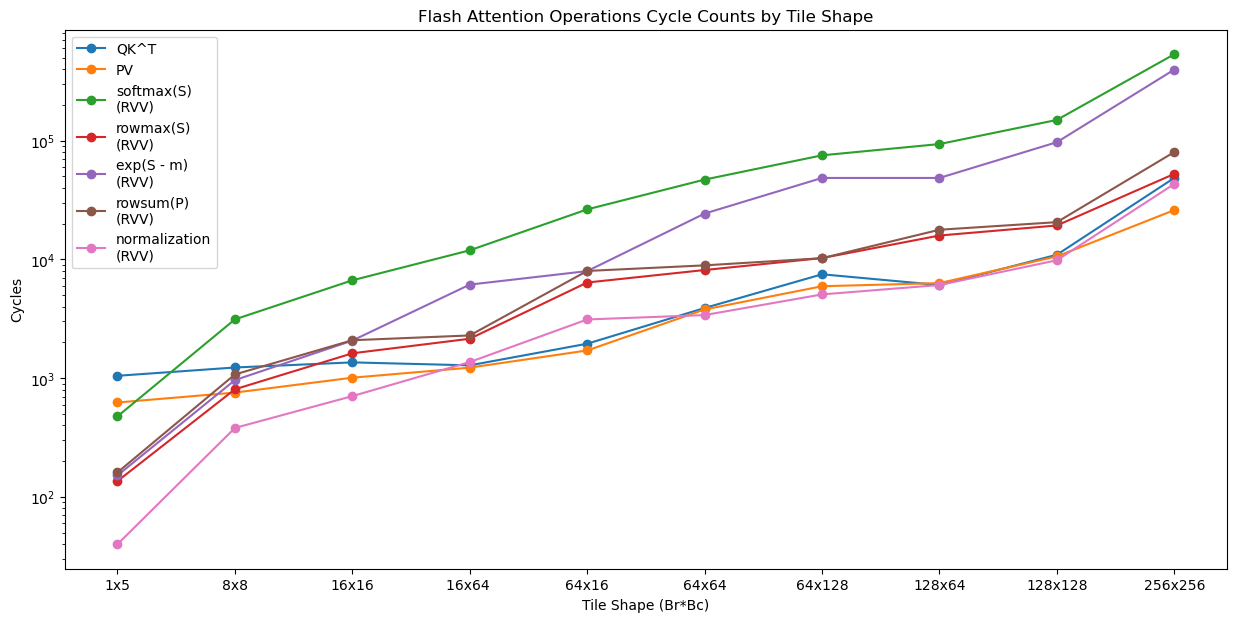

In [5]:
# 分操作可视化周期数
operations = df_inner.index.tolist()
shapes = df_inner.columns.tolist()
plt.figure(figsize=(15, 7))
for i, operation in enumerate(operations):
    plt.plot(shapes, df_inner.loc[operation], marker='o', label=operation)

plt.yscale('log')
plt.xlabel("Tile Shape (Br*Bc)")
plt.ylabel("Cycles")
plt.title("Flash Attention Operations Cycle Counts by Tile Shape")
plt.legend()

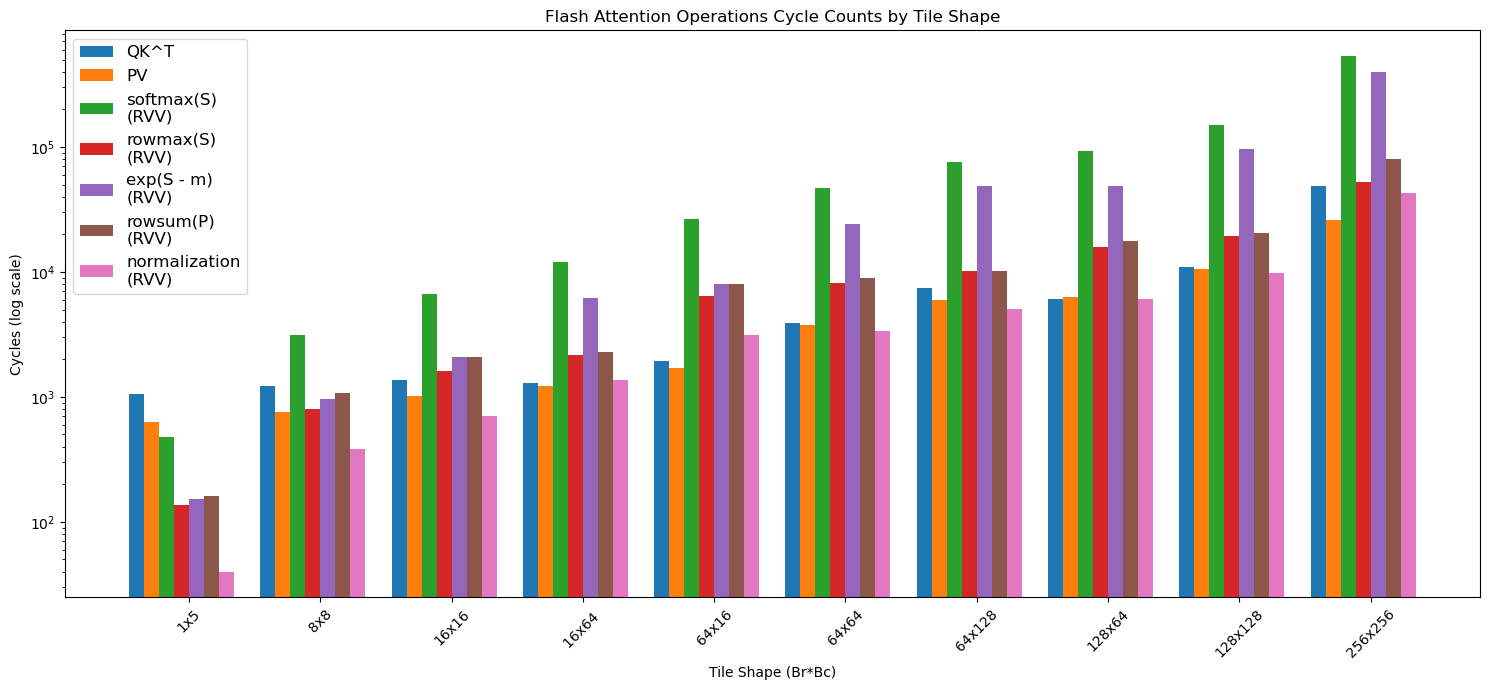

In [6]:
x = np.arange(len(shapes))
width = 0.8 / len(operations)

plt.figure(figsize=(15, 7))
for i, operation in enumerate(operations):
    plt.bar(x + i * width, df_inner.loc[operation], width, label=operation)

plt.yscale('log')
plt.xlabel("Tile Shape (Br*Bc)")
plt.ylabel("Cycles (log scale)")
plt.title("Flash Attention Operations Cycle Counts by Tile Shape")
plt.xticks(x + width * len(operations) / 2, shapes, rotation=45)
plt.legend(loc='upper left', fontsize='large')
plt.tight_layout()

### 相对占比随分块大小的变化

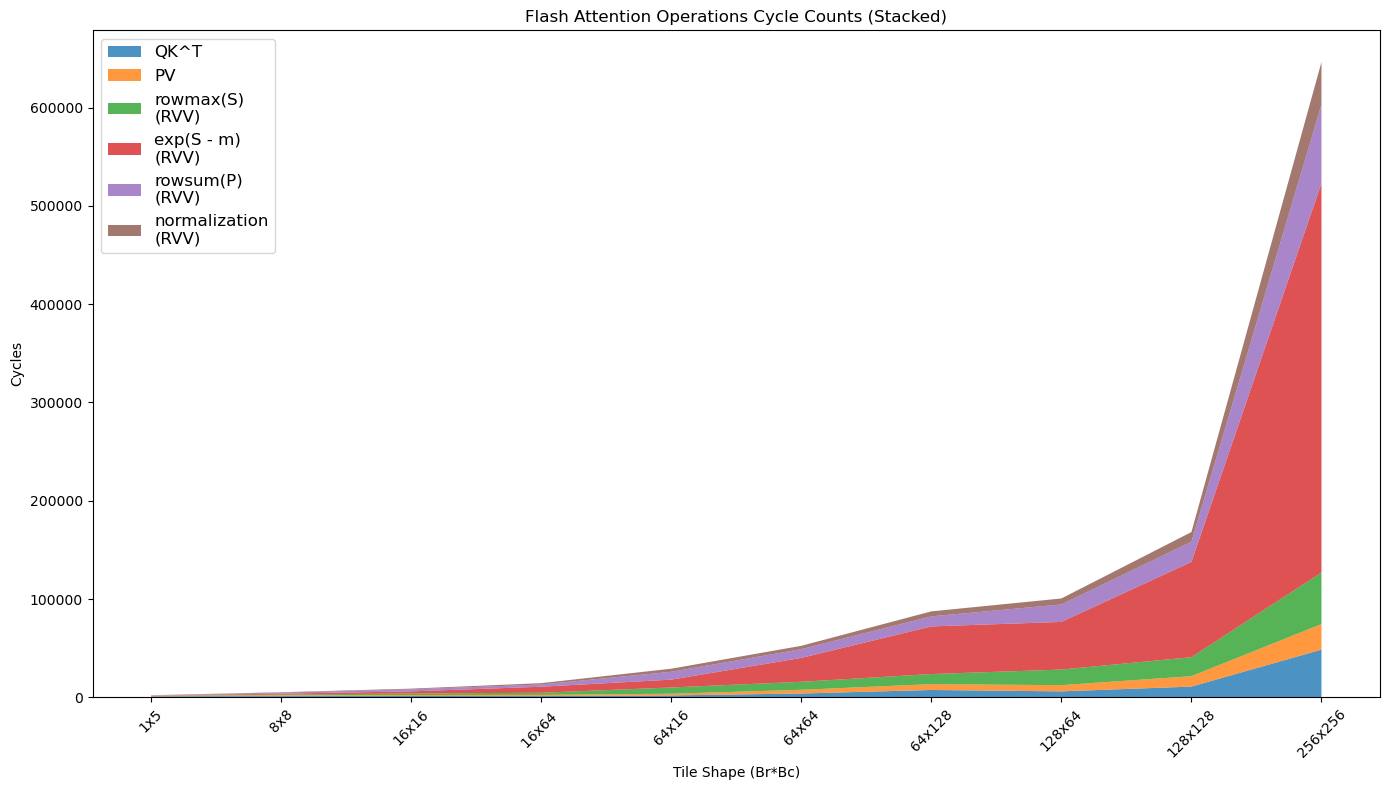

In [7]:
# 分操作可视化周期数 - 堆叠面积图
df_withoutSoftmax = df_inner.drop(index="softmax(S)\n(RVV)",inplace=False)
operations = df_withoutSoftmax.index.tolist()
shapes = df_withoutSoftmax.columns.tolist()

plt.figure(figsize=(14, 8))
plt.stackplot(range(len(shapes)), [df_withoutSoftmax.loc[op] for op in operations], 
              labels=operations, alpha=0.8)
plt.xticks(range(len(shapes)), shapes, rotation=45)
plt.xlabel("Tile Shape (Br*Bc)")
plt.ylabel("Cycles")
plt.title("Flash Attention Operations Cycle Counts (Stacked)")
plt.legend(loc='upper left', fontsize='large')
plt.tight_layout()

## Single Head Function

统计单头Flash Attention在不同Sequence Length，不同Tile Shape下的时长分布

In [8]:
df_single_head_per_seq = pd.read_excel(io="data/single_head_cycles_cnt.xlsx", sheet_name="Single Head (per seq length)", header=0, index_col=0)
df_single_head_per_seq.drop(axis='index', index="单位：周期数 / Head Dimension取64 / Tile Shape固定Br*Bc = 128*128", inplace=True)
df_single_head_per_seq

,128,256,512,1024,2048
QK^T,10256.0,28936.0,94451.0,328928.0,1282441.0
PV,8433.0,24922.0,82846.0,298817.0,1238189.0
softmax(S)\n(including mask & dequant),156079.0,503148.0,1784897.0,6643962.0,22672136.0
output accum & dequat,11659.0,38920.0,140151.0,529537.0,2041935.0
normalization,7616.0,14984.0,32257.0,70059.0,162283.0
initialization & other overheads,68811.0,160849.0,433010.0,1397779.0,4555557.0
TOTAL,262854.0,771759.0,2567612.0,9269082.0,47676431.0


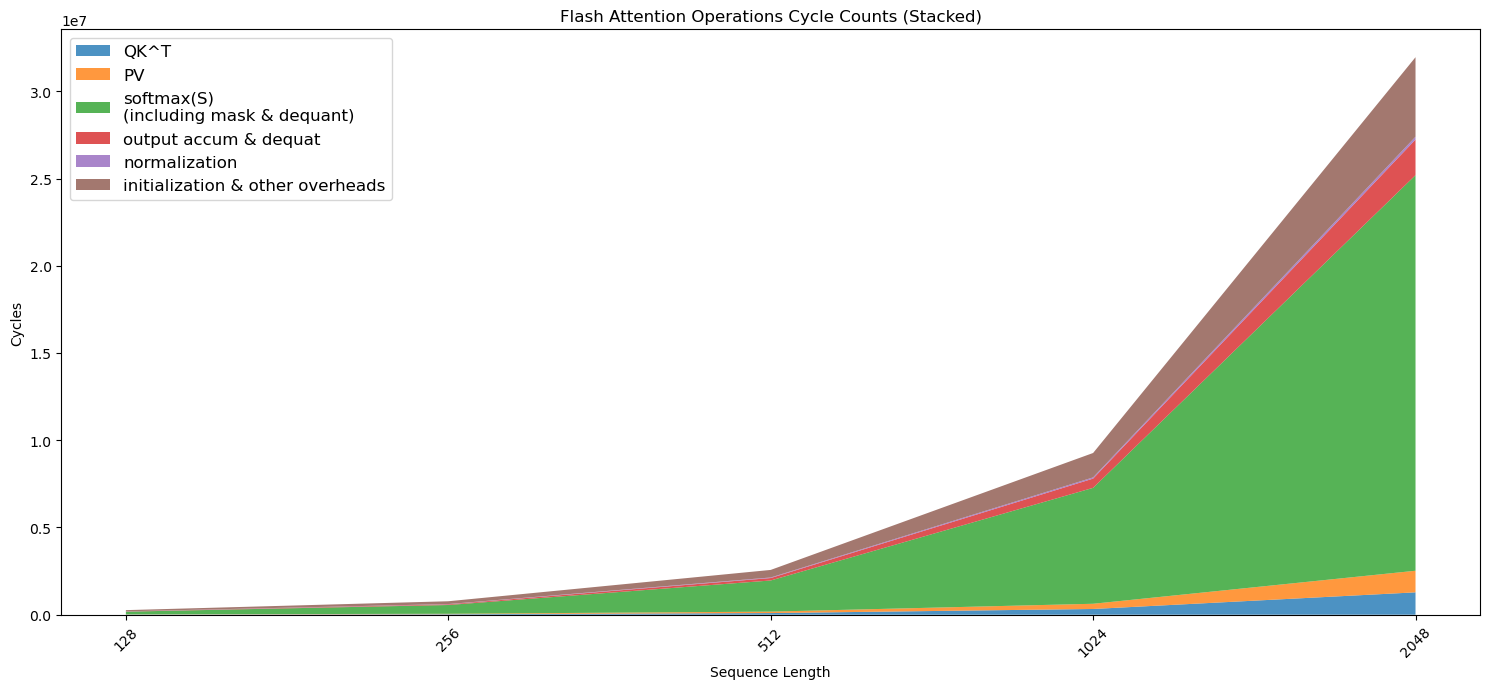

In [9]:
df_withoutTotal = df_single_head_per_seq.drop(index="TOTAL", inplace=False)
operations = df_withoutTotal.index.tolist()
sequence_length = df_withoutTotal.columns.tolist()

plt.figure(figsize=(15, 7))
plt.stackplot(range(len(sequence_length)), [df_withoutTotal.loc[op] for op in operations], labels=operations, alpha=0.8)
plt.xticks(range(len(sequence_length)), sequence_length, rotation=45)
plt.xlabel("Sequence Length")
plt.ylabel("Cycles")
plt.title("Flash Attention Operations Cycle Counts (Stacked)")
plt.legend(loc='upper left', fontsize='large')
plt.tight_layout()

In [10]:
df_single_head_per_tile = pd.read_excel(io="data/single_head_cycles_cnt.xlsx", sheet_name="Single Head (per tile shape)", header=0, index_col=0)
df_single_head_per_tile.drop(axis='index', index="单位：周期数 / Head Dimension取64 / Sequence Length固定1k", inplace=True)
df_single_head_per_tile

,8x8,16x16,32x32,64x64,128x64,128x128,256x256
QK^T,NaN,NaN,NaN,401124.0,NaN,328928.0,NaN
PV,NaN,NaN,NaN,375532.0,NaN,298817.0,NaN
softmax(S)\n(including mask & dequant),NaN,NaN,NaN,8053955.0,NaN,6643962.0,NaN
output accum & dequat,NaN,NaN,NaN,1118502.0,NaN,529537.0,NaN
normalization,NaN,NaN,NaN,62713.0,NaN,70059.0,NaN
initialization & other overheads,NaN,NaN,NaN,2045089.0,NaN,1397779.0,NaN
TOTAL,NaN,NaN,NaN,12056915.0,NaN,9269082.0,NaN


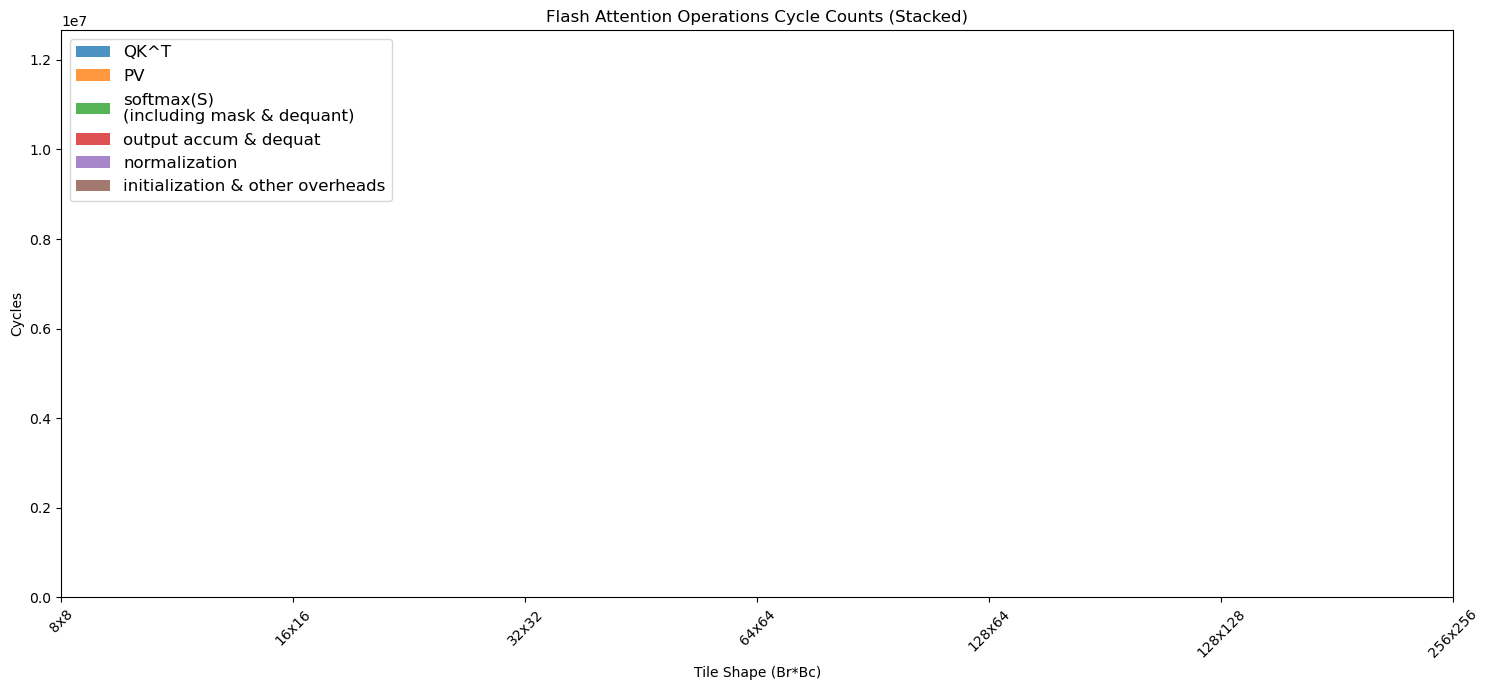

In [11]:
df_withoutTotal = df_single_head_per_tile.drop(index="TOTAL", inplace=False)
operations = df_withoutTotal.index.tolist()
tile_shapes = df_withoutTotal.columns.tolist()

plt.figure(figsize=(15, 7))
plt.stackplot(range(len(tile_shapes)), [df_withoutTotal.loc[op] for op in operations], labels=operations, alpha=0.8)
plt.xticks(range(len(tile_shapes)), tile_shapes, rotation=45)
plt.xlabel("Tile Shape (Br*Bc)")
plt.ylabel("Cycles")
plt.title("Flash Attention Operations Cycle Counts (Stacked)")
plt.legend(loc='upper left', fontsize='large')
plt.tight_layout()